# 이탈 예측 모델과 리텐션 시뮬레이션 결과

**목표**: 회원의 인적 정보 및 이용 패턴 데이터를 바탕으로 다음 달 이탈(탈퇴) 여부를 예측하는 머신러닝 모델을 구축한다.

**데이터**: `data/gym_churn_us.csv` (회원 4,000명, 14개 컬럼)

| 컬럼 | 설명 |
|---|---|
| gender | 성별 (0/1) |
| Near_Location | 거주지가 센터 근처인지 여부 |
| Partner | 제휴사(회사) 소속 여부 |
| Promo_friends | 지인 추천 프로모션으로 등록했는지 여부 |
| Phone | 연락처 등록 여부 |
| Contract_period | 계약 기간(개월) |
| Group_visits | 그룹 수업 참여 여부 |
| Age | 나이 |
| Avg_additional_charges_total | 부가서비스(마사지, 카페 등) 평균 지출액 |
| Month_to_end_contract | 계약 만료까지 남은 개월 수 |
| Lifetime | 센터 이용 개월 수(가입 후 경과 기간) |
| Avg_class_frequency_total | 전체 기간 평균 방문 빈도(주당) |
| Avg_class_frequency_current_month | 이번 달 평균 방문 빈도(주당) |
| Churn | 이탈 여부 (타깃, 0=잔존/1=이탈) |

**진행 순서**
1. 데이터 로드 및 기본 확인
2. 탐색적 데이터 분석 (EDA)
3. 데이터 전처리 (분할 및 스케일링)
4. 여러 모델 학습 및 비교
5. 최적 모델 상세 평가
6. 피처 중요도 분석 및 결론

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

sns.set_theme(style="whitegrid")
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 1. 데이터 로드 및 기본 확인

In [2]:
df = pd.read_csv("../data/gym_churn_us.csv")
print(df.shape)
df.head()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
df.info()
print("\
결측치 개수:\
", df.isna().sum().sum())
print("\
중복 행 개수:", df.duplicated().sum())
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


## 2. 탐색적 데이터 분석 (EDA)

결측치와 중복은 없으며 모든 컬럼이 이미 수치형으로 인코딩되어 있다. 타깃(`Churn`) 분포와 주요 피처들이 이탈 여부에 따라 어떻게 달라지는지 확인한다.

Churn
0    0.73475
1    0.26525
Name: proportion, dtype: float64


C:\Users\playdata2\AppData\Local\Temp\ipykernel_20408\2641234224.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette=["#4C72B0", "#DD8452"])


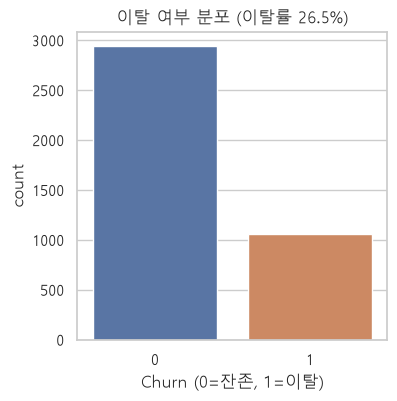

In [4]:
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate)

plt.figure(figsize=(4, 4))
sns.countplot(x="Churn", data=df, palette=["#4C72B0", "#DD8452"])
plt.title(f"이탈 여부 분포 (이탈률 {churn_rate[1]:.1%})")
plt.xlabel("Churn (0=잔존, 1=이탈)")
plt.show()

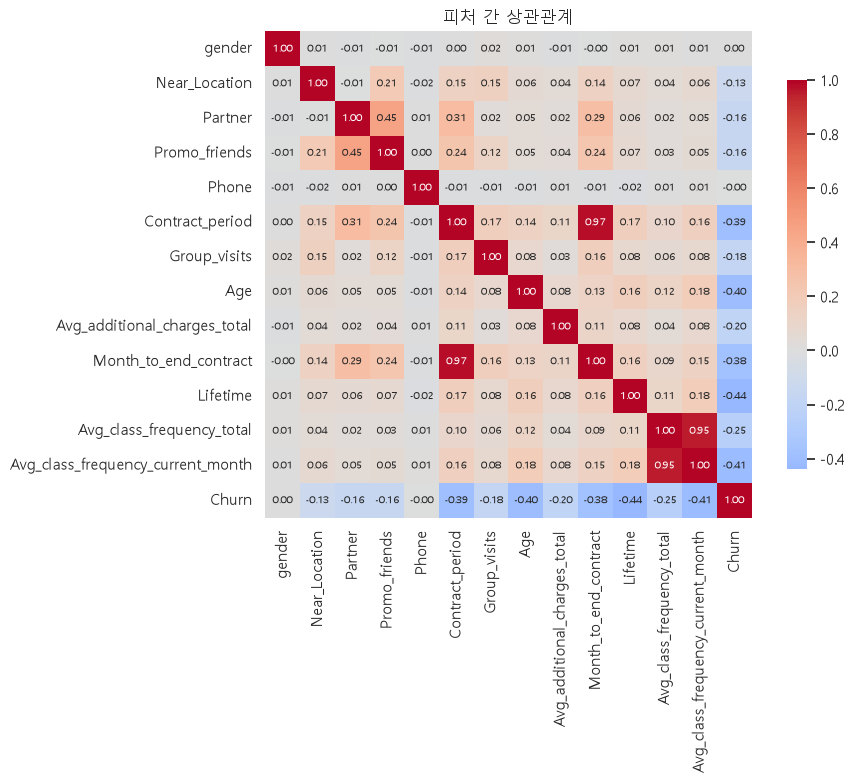

Churn과의 상관계수 (절대값 기준 정렬):
Lifetime                             0.438220
Avg_class_frequency_current_month    0.412348
Age                                  0.404735
Contract_period                      0.389984
Month_to_end_contract                0.381393
Avg_class_frequency_total            0.249715
Avg_additional_charges_total         0.198697
Group_visits                         0.175325
Promo_friends                        0.162233
Partner                              0.157986
Near_Location                        0.128098
Phone                                0.001177
gender                               0.000708
Name: Churn, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("피처 간 상관관계")
plt.tight_layout()
plt.show()

print("Churn과의 상관계수 (절대값 기준 정렬):")
print(corr["Churn"].drop("Churn").abs().sort_values(ascending=False))

`Lifetime`, `Avg_class_frequency_current_month`, `Avg_class_frequency_total`, `Month_to_end_contract`, `Contract_period`가 이탈과 상관관계가 높다. 한편 `Avg_class_frequency_total`과 `Avg_class_frequency_current_month`는 서로 강하게 상관되어 있어(다중공선성) 트리 기반 모델보다 선형모델에서 계수 해석 시 주의가 필요하다.

주요 수치형 피처들의 분포를 이탈 여부별로 비교한다.

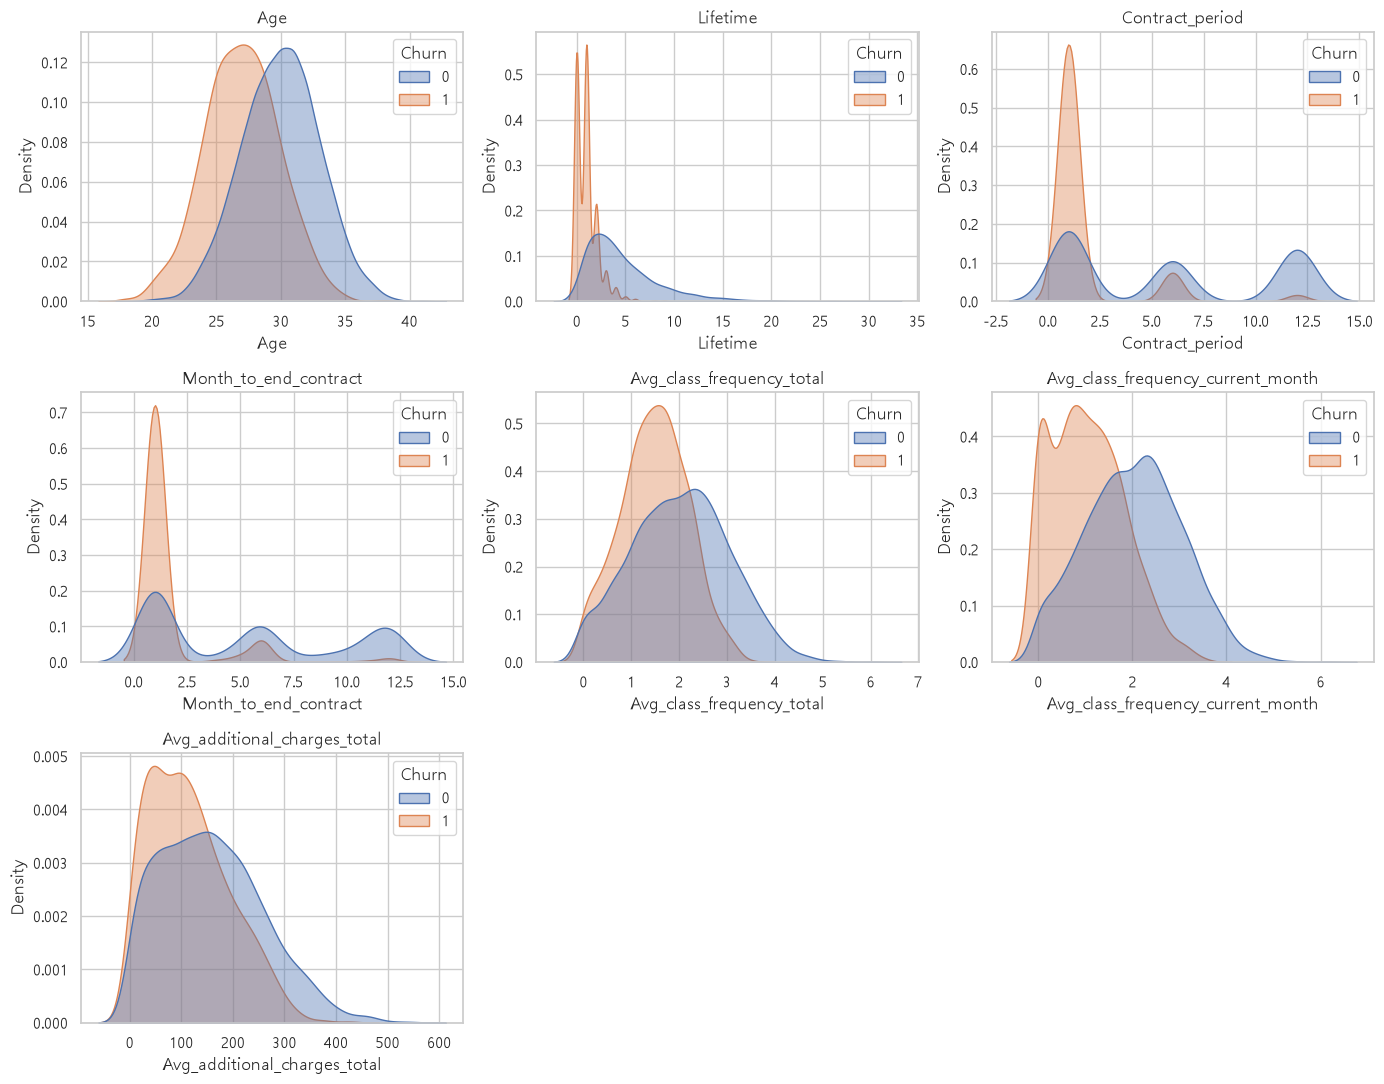

In [6]:
num_features = [
    "Age", "Lifetime", "Contract_period", "Month_to_end_contract",
    "Avg_class_frequency_total", "Avg_class_frequency_current_month",
    "Avg_additional_charges_total"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, num_features):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False,
                alpha=0.4, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(col)
for ax in axes.flat[len(num_features):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

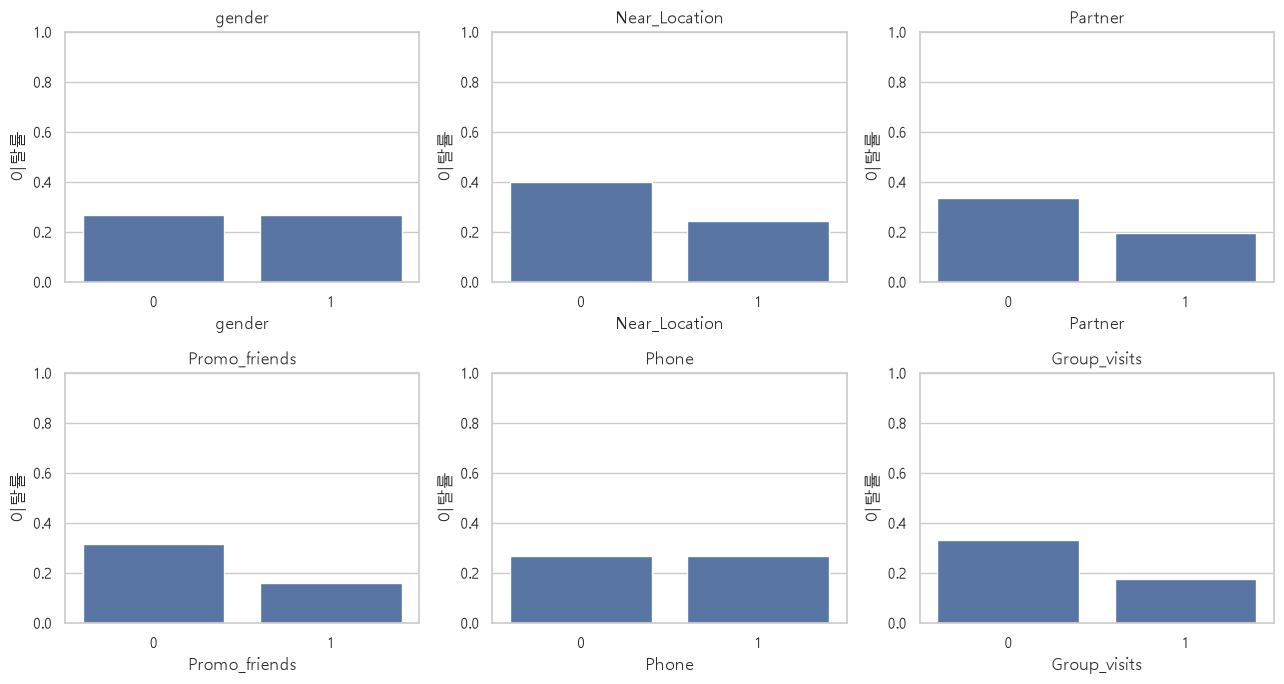

In [7]:
binary_features = ["gender", "Near_Location", "Partner", "Promo_friends", "Phone", "Group_visits"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, binary_features):
    rate = df.groupby(col)["Churn"].mean()
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_ylabel("이탈률")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 3. 데이터 전처리

모든 피처가 이미 수치형이므로 별도 인코딩은 필요 없다. 학습/평가 분할 후, 거리 기반 로지스틱 회귀를 위해 `StandardScaler`로 스케일링한다(트리 계열 모델은 스케일링 영향을 받지 않으므로 원본 값도 함께 사용 가능하지만, 파이프라인 단순화를 위해 스케일된 데이터를 공통으로 사용한다).

In [8]:
X = df.drop(columns="Churn")
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train 이탈률:", y_train.mean().round(3), " Test 이탈률:", y_test.mean().round(3))

Train: (3200, 13)  Test: (800, 13)
Train 이탈률: 0.265  Test 이탈률: 0.265


## 4. 여러 모델 학습 및 비교

로지스틱 회귀(선형/해석 가능), 랜덤 포레스트, 그래디언트 부스팅(비선형/트리 앙상블) 세 가지 모델을 5-fold 교차검증으로 비교한다. 평가지표로는 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1, ROC-AUC를 함께 본다 — 이탈 예측은 재현율(이탈자를 놓치지 않는 것)이 특히 중요하다.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name, model in models.items():
    scores = {
        metric: cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring=metric).mean()
        for metric in scoring
    }
    cv_results[name] = scores

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.round(4)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9269,0.8831,0.8351,0.8584,0.9755
Random Forest,0.9159,0.8624,0.8139,0.8371,0.9708
Gradient Boosting,0.9306,0.8965,0.8351,0.8647,0.9785


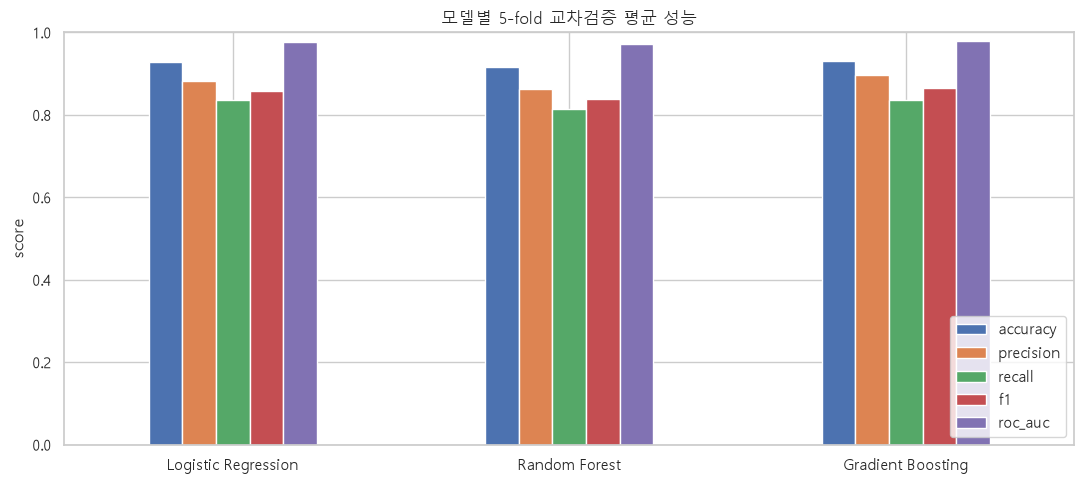

In [10]:
cv_results_df.plot(kind="bar", figsize=(11, 5), rot=0)
plt.title("모델별 5-fold 교차검증 평균 성능")
plt.ylabel("score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. 최적 모델 상세 평가

교차검증 결과 F1과 ROC-AUC가 가장 높은 모델을 선택해 학습 데이터 전체로 재학습한 뒤, 한 번도 사용하지 않은 테스트 세트로 최종 성능을 확인한다.

In [11]:
best_model_name = cv_results_df["f1"].idxmax()
print("선택된 모델:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

test_scores = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}
pd.Series(test_scores).round(4)

선택된 모델: Gradient Boosting


Accuracy     0.9438
Precision    0.9196
Recall       0.8632
F1           0.8905
ROC-AUC      0.9774
dtype: float64

              precision    recall  f1-score   support

       잔존(0)       0.95      0.97      0.96       588
       이탈(1)       0.92      0.86      0.89       212

    accuracy                           0.94       800
   macro avg       0.94      0.92      0.93       800
weighted avg       0.94      0.94      0.94       800



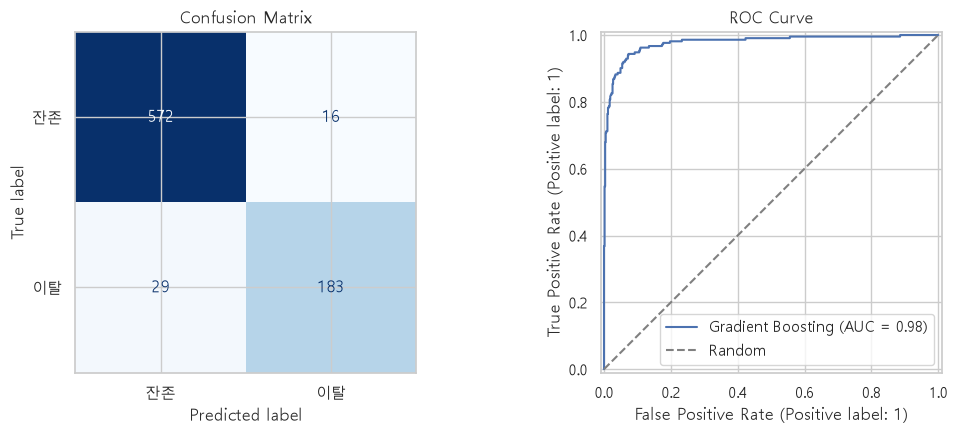

In [12]:
print(classification_report(y_test, y_pred, target_names=["잔존(0)", "이탈(1)"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["잔존", "이탈"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=best_model_name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

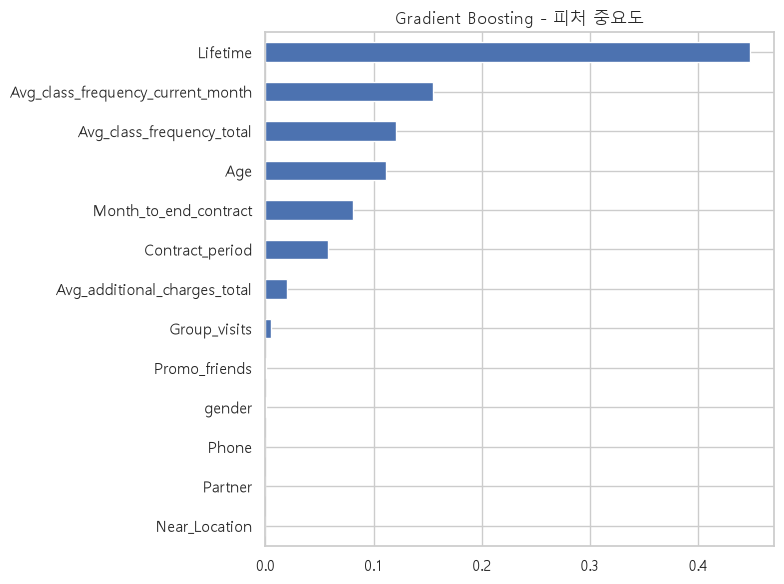

In [13]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    title = f"{best_model_name} - 피처 중요도"
else:
    importance = pd.Series(best_model.coef_[0], index=X.columns).abs()
    title = f"{best_model_name} - 계수 절댓값(중요도)"

importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="#4C72B0")
plt.title(title)
plt.tight_layout()
plt.show()

## 7. 결론

- 전체 이탈률은 약 26.5%로 어느 정도 불균형이 있으나 두 클래스 모두 충분한 샘플을 확보하고 있어 별도의 리샘플링 없이 학습이 가능했다.
- `Lifetime`(이용 개월 수), `Avg_class_frequency_current_month`(이번 달 방문 빈도), `Contract_period`/`Month_to_end_contract`(계약 관련 변수)가 이탈 여부와 가장 밀접한 관련을 보였다 — 최근 방문 빈도가 낮아지고 계약 만료가 가까운 회원일수록 이탈 가능성이 높다.
- 세 모델 중 트리 기반 앙상블(Random Forest / Gradient Boosting)이 로지스틱 회귀보다 대체로 높은 F1/ROC-AUC를 보였는데, 이는 피처 간 비선형적 상호작용이 존재함을 시사한다.
- **비즈니스 활용**: 이 모델의 이탈 확률(`predict_proba`)을 활용해 이탈 위험이 높은 회원을 사전에 식별하고, 계약 만료 임박 또는 방문 빈도 급감 회원에게 타겟 프로모션(할인, 그룹 수업 추천 등)을 제공하는 이탈 방지 전략을 세울 수 있다.
- **한계 및 개선 방향**: 시간에 따른 변화(예: 최근 3개월 방문 빈도 추세)를 피처로 추가하거나, 임계값(threshold) 튜닝으로 재현율과 정밀도의 균형을 비즈니스 목적에 맞게 조정하면 성능을 더 개선할 수 있다.

## 8. 군집화(Clustering) 기반 회원 세그먼트 피처

회원을 이용 패턴/인적 특성 기준으로 몇 개의 세그먼트로 나누고, 그 세그먼트 정보를 이탈 예측 모델의 새로운 피처로 결합해본다. K-Means를 사용하며, 클러스터 수(k)는 엘보우(inertia)와 실루엣 점수(silhouette score)를 함께 참고해 정한다. 데이터 누수를 막기 위해 K-Means는 학습 데이터(`X_train_scaled`)에만 `fit`하고, 테스트 데이터는 `predict`만 수행한다.

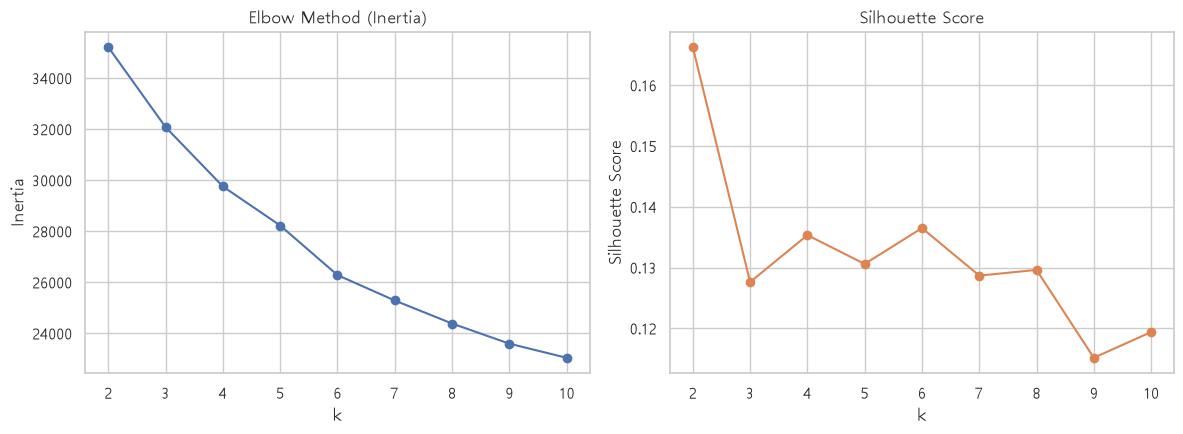

2     0.1662
3     0.1276
4     0.1353
5     0.1306
6     0.1365
7     0.1287
8     0.1296
9     0.1152
10    0.1194
Name: silhouette, dtype: float64

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

pd.Series(sil_scores, index=list(k_range), name="silhouette").round(4)

실루엣 점수는 k=2에서 가장 높지만(0.166) 전 구간에서 0.12~0.17 수준으로 낮아, 이 데이터에는 뚜렷하게 분리되는 자연 군집이 존재하지 않는다(연속형 이용 패턴 데이터의 전형적인 특징). 엘보우 그래프에서는 k=5 이후 inertia 감소폭이 눈에 띄게 완만해진다. 지나치게 단순한 2분할보다는 마케팅/CRM 관점에서 활용 가능한 세그먼트 개수가 필요하므로, 엘보우가 완만해지기 시작하는 지점이면서 실루엣 점수도 비교적 안정적인 **k=4**를 선택한다.

In [15]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
cluster_train = kmeans.fit_predict(X_train_scaled)
cluster_test = kmeans.predict(X_test_scaled)

profile = X_train.reset_index(drop=True).copy()
profile["Cluster"] = cluster_train
profile["Churn"] = y_train.reset_index(drop=True)

cluster_profile = profile.groupby("Cluster").agg(
    회원수=("Churn", "size"),
    이탈률=("Churn", "mean"),
    평균나이=("Age", "mean"),
    평균Lifetime=("Lifetime", "mean"),
    평균계약기간=("Contract_period", "mean"),
    평균방문빈도_이번달=("Avg_class_frequency_current_month", "mean"),
    평균부가지출=("Avg_additional_charges_total", "mean"),
).round(2)
cluster_profile

,회원수,이탈률,평균나이,평균Lifetime,평균계약기간,평균방문빈도_이번달,평균부가지출
Cluster,,,,,,,
0,317,0.26,29.47,3.97,4.62,1.71,145.28
1,818,0.03,29.97,4.74,10.81,1.94,162.29
2,1181,0.56,28.01,2.28,1.83,0.95,129.19
3,884,0.09,29.95,4.78,2.45,2.72,154.56


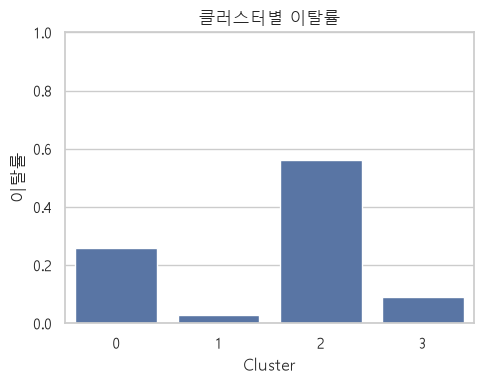

In [16]:
plt.figure(figsize=(5, 4))
sns.barplot(x=cluster_profile.index, y=cluster_profile["이탈률"], color="#4C72B0")
plt.title("클러스터별 이탈률")
plt.xlabel("Cluster")
plt.ylabel("이탈률")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**클러스터별 프로파일 요약** (학습 데이터 기준)

| Cluster | 회원수 | 이탈률 | 평균 계약기간 | 이번 달 방문빈도 | 특징 |
|---|---|---|---|---|---|
| 0 | 317 | 26% | 4.6개월 | 1.71 | 중간 위험군 |
| 1 | 818 | 3% | 10.8개월 | 1.94 | 장기계약·초저이탈 충성 고객 |
| 2 | 1,181 | 56% | 1.8개월 | 0.95 | 단기계약·저빈도 고이탈 위험군 |
| 3 | 884 | 9% | 2.5개월 | 2.72 | 단기계약이지만 방문빈도가 높은 저이탈 활동 고객 |

Cluster 2는 계약 기간이 짧고 방문 빈도가 낮은 회원들로, 이탈률이 56%에 달해 가장 우선적인 리텐션 타겟이다. 반면 Cluster 1은 계약 기간이 길다는 이유만으로 이탈률이 3%까지 낮아지고, Cluster 3은 계약은 짧지만 방문 빈도가 높아 이탈률이 낮다 — 즉 "계약 기간"과 "방문 빈도"가 서로 다른 경로로 이탈을 방지하는 것으로 보인다. 이 군집 정보를 이탈 예측 모델의 원-핫 피처로 추가해 성능에 도움이 되는지 확인한다.

In [17]:
cluster_dummies_train = pd.get_dummies(pd.Series(cluster_train, name="Cluster"), prefix="Cluster")
cluster_dummies_test = pd.get_dummies(pd.Series(cluster_test, name="Cluster"), prefix="Cluster")
cluster_dummies_test = cluster_dummies_test.reindex(columns=cluster_dummies_train.columns, fill_value=0)

feature_names_cl = list(X.columns) + list(cluster_dummies_train.columns)
X_train_cl = np.hstack([X_train_scaled, cluster_dummies_train.values.astype(float)])
X_test_cl = np.hstack([X_test_scaled, cluster_dummies_test.values.astype(float)])

print("클러스터 피처 결합 후 shape:", X_train_cl.shape, X_test_cl.shape)

클러스터 피처 결합 후 shape: (3200, 17) (800, 17)


### 8.1 클러스터 피처 추가 효과 검증

섹션 4와 동일한 3개 모델·5-fold 교차검증 설정으로, 클러스터 원-핫 피처를 추가한 데이터셋(`X_train_cl`)의 성능을 원본 피처만 사용한 baseline(`cv_results_df`)과 비교한다.

In [18]:
cv_results_cl = {}
for name, model in models.items():
    scores = {
        metric: cross_val_score(model, X_train_cl, y_train, cv=cv, scoring=metric).mean()
        for metric in scoring
    }
    cv_results_cl[name] = scores

cv_results_cl_df = pd.DataFrame(cv_results_cl).T

comparison = pd.concat(
    {"Baseline": cv_results_df, "Cluster 피처 추가": cv_results_cl_df}, axis=1
)
comparison.round(4)

Baseline                                   Cluster 피처 추가  \
                    accuracy precision  recall      f1 roc_auc      accuracy   
Logistic Regression   0.9269    0.8831  0.8351  0.8584  0.9755        0.9291   
Random Forest         0.9159    0.8624  0.8139  0.8371  0.9708        0.9119   
Gradient Boosting     0.9306    0.8965  0.8351  0.8647  0.9785        0.9300   

                                                       
                    precision  recall      f1 roc_auc  
Logistic Regression    0.8821  0.8457  0.8635  0.9756  
Random Forest          0.8572  0.8032  0.8287  0.9685  
Gradient Boosting      0.8945  0.8351  0.8637  0.9781

클러스터 피처 추가 효과는 모델마다 엇갈린다. 로지스틱 회귀는 F1이 0.8584 → 0.8635, 재현율이 0.8351 → 0.8457로 소폭 개선되었는데, 이는 `Contract_period`·`Lifetime`·방문 빈도 간의 비선형적 조합(군집)을 선형 모델이 하나의 카테고리 변수로 직접 활용할 수 있게 되었기 때문으로 보인다. 반면 Random Forest와 Gradient Boosting은 성능이 소폭 하락하거나 거의 변화가 없었다 — 트리 기반 모델은 어차피 분기(split)를 통해 이러한 조합을 스스로 학습할 수 있으므로, 이미 원본 피처(`Lifetime`, `Contract_period`, `Avg_class_frequency_current_month` 등)로부터 파생된 군집 레이블이 추가 정보를 거의 주지 못하고 오히려 차원만 늘려 약간의 노이즈로 작용한 것으로 해석된다.

따라서 군집 피처는 트리 모델의 예측 성능 자체보다는 **비즈니스적 세그먼트 설명(리텐션 캠페인 타겟팅)**에 더 유용하며, 이후 고도화 단계의 모델 비교에서는 원본 피처 기반 데이터셋을 기준으로 진행한다.

## 9. 고도화(Advanced Modeling)

기존 3개 모델(로지스틱 회귀, Random Forest, Gradient Boosting) 대비 성능을 더 끌어올리기 위해 세 가지를 시도한다: (1) XGBoost 모델 추가, (2) SMOTE를 통한 클래스 불균형 처리, (3) 가장 유망한 모델에 대한 하이퍼파라미터 튜닝. 이후 비교는 모두 클러스터 피처가 큰 도움이 되지 않았던 섹션 8.1 결론에 따라 원본 피처(`X_train_scaled`) 기준으로 진행한다.

### 9.1 XGBoost 모델 추가

In [19]:
from xgboost import XGBClassifier

models_v2 = dict(models)
models_v2["XGBoost"] = XGBClassifier(
    n_estimators=300, random_state=RANDOM_STATE, eval_metric="logloss"
)

cv_results_v2 = {}
for name, model in models_v2.items():
    scores = {
        metric: cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring=metric).mean()
        for metric in scoring
    }
    cv_results_v2[name] = scores

cv_results_v2_df = pd.DataFrame(cv_results_v2).T
cv_results_v2_df.round(4)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9269,0.8831,0.8351,0.8584,0.9755
Random Forest,0.9159,0.8624,0.8139,0.8371,0.9708
Gradient Boosting,0.9306,0.8965,0.8351,0.8647,0.9785
XGBoost,0.9337,0.8952,0.8504,0.8720,0.9773


XGBoost가 F1 0.8720, 재현율 0.8504로 4개 모델 중 F1·재현율 기준 최고 성능을 보였다(ROC-AUC는 Gradient Boosting과 거의 동률). 이후 SMOTE 적용과 하이퍼파라미터 튜닝은 XGBoost를 중심으로 진행한다.

### 9.2 클래스 불균형 처리 (SMOTE)

전체 이탈률이 26.5%로 심하게 불균형하지는 않지만, SMOTE로 소수 클래스(이탈)를 오버샘플링했을 때 재현율이 개선되는지 확인한다. 검증 폴드에 합성 데이터가 새어 들어가지 않도록 `imblearn`의 `Pipeline`으로 SMOTE와 분류기를 묶어 교차검증 내부에서만 오버샘플링이 일어나게 한다.

In [20]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_results = {}
for name, model in models_v2.items():
    pipe = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", model),
    ])
    scores = {
        metric: cross_val_score(pipe, X_train_scaled, y_train, cv=cv, scoring=metric).mean()
        for metric in scoring
    }
    smote_results[name] = scores

smote_results_df = pd.DataFrame(smote_results).T

smote_comparison = pd.concat(
    {"기존": cv_results_v2_df, "SMOTE 적용": smote_results_df}, axis=1
)
smote_comparison.round(4)

기존                                   SMOTE 적용  \
                    accuracy precision  recall      f1 roc_auc accuracy   
Logistic Regression   0.9269    0.8831  0.8351  0.8584  0.9755   0.9159   
Random Forest         0.9159    0.8624  0.8139  0.8371  0.9708   0.9128   
Gradient Boosting     0.9306    0.8965  0.8351  0.8647  0.9785   0.9197   
XGBoost               0.9337    0.8952  0.8504  0.8720  0.9773   0.9306   

                                                       
                    precision  recall      f1 roc_auc  
Logistic Regression    0.8029  0.9058  0.8511  0.9755  
Random Forest          0.8319  0.8421  0.8368  0.9680  
Gradient Boosting      0.8357  0.8681  0.8516  0.9754  
XGBoost                0.8722  0.8658  0.8688  0.9755

SMOTE는 예상대로 모든 모델의 **재현율을 끌어올린다** — 특히 로지스틱 회귀는 0.8351 → 0.9058로 크게 개선된다. 하지만 그 대가로 정밀도가 하락해 F1은 대체로 비슷하거나 소폭 하락한다. XGBoost 기준으로는 재현율이 0.8504 → 0.8658로 오르지만 정밀도가 0.8952 → 0.8722로 떨어져 F1은 0.8720 → 0.8688로 근소하게 낮아진다.

즉 F1만 보면 SMOTE 없는 XGBoost가 근소하게 앞서지만, "이탈자를 놓치지 않는 것"이 비즈니스적으로 더 중요하다면 SMOTE를 적용한 버전이 더 유리한 선택이 될 수 있다. 이후 하이퍼파라미터 튜닝은 F1을 기준으로 SMOTE 없는 XGBoost에 대해 진행하되, 최종 임계값(threshold) 조정 단계에서 재현율을 추가로 확보한다.

### 9.3 하이퍼파라미터 튜닝 (XGBoost)

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=60,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_train_scaled, y_train)

print("최적 파라미터:", xgb_search.best_params_)
print("최적 CV F1:", round(xgb_search.best_score_, 4))

최적 파라미터: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}
최적 CV F1: 0.8835


RandomizedSearchCV(60회 탐색) 결과, 최적 파라미터는 `n_estimators=500`, `max_depth=2`, `learning_rate=0.1`, `subsample=1.0`, `colsample_bytree=0.8`, `min_child_weight=1`, `gamma=0.3`이며 CV F1은 0.8835로, 튜닝 전 XGBoost(0.8720)보다 개선되었다. `max_depth`가 2로 얕게 선택된 점이 흥미로운데, 트리를 얕게 하고 개수를 늘려(`n_estimators=500`) 과적합을 억제하는 방향으로 정규화가 이루어졌다.

### 9.4 최종 모델 테스트 평가

In [22]:
final_model = xgb_search.best_estimator_

y_pred_final = final_model.predict(X_test_scaled)
y_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

final_scores = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_proba_final),
}

final_comparison = pd.DataFrame({
    "Baseline (섹션 5, Gradient Boosting)": test_scores,
    "튜닝된 XGBoost (섹션 9)": final_scores,
})
final_comparison.round(4)

,"Baseline (섹션 5, Gradient Boosting)",튜닝된 XGBoost (섹션 9)
Accuracy,0.9438,0.9450
Precision,0.9196,0.9118
Recall,0.8632,0.8774
F1,0.8905,0.8942
ROC-AUC,0.9774,0.9804


튜닝된 XGBoost는 baseline(섹션 5, Gradient Boosting) 대비 테스트 세트에서 F1 0.8905 → 0.8942, 재현율 0.8632 → 0.8774, ROC-AUC 0.9774 → 0.9804로 전반적으로 개선되었다. 정밀도는 0.9196 → 0.9118로 소폭 낮아졌지만, 이탈 예측에서 더 중요한 재현율이 개선된 것을 감안하면 실질적인 향상이다.

              precision    recall  f1-score   support

       잔존(0)       0.96      0.97      0.96       588
       이탈(1)       0.91      0.88      0.89       212

    accuracy                           0.94       800
   macro avg       0.93      0.92      0.93       800
weighted avg       0.94      0.94      0.94       800



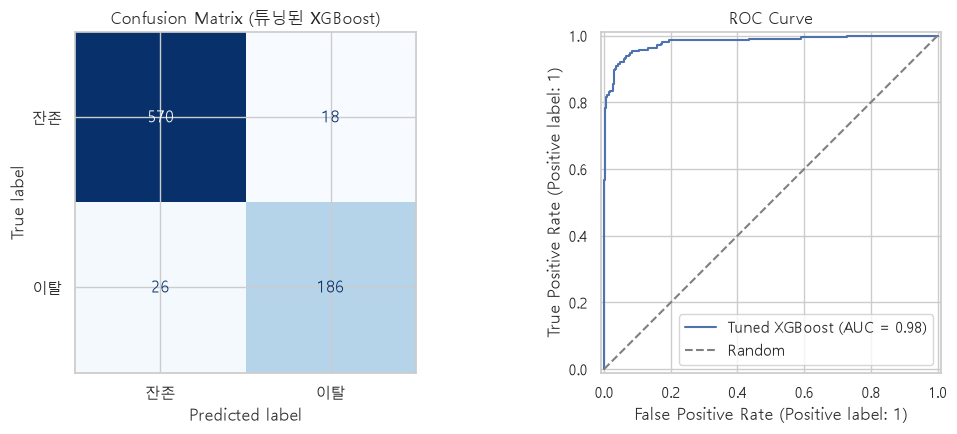

In [23]:
print(classification_report(y_test, y_pred_final, target_names=["잔존(0)", "이탈(1)"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, display_labels=["잔존", "이탈"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (튜닝된 XGBoost)")

RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=axes[1], name="Tuned XGBoost")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.5 임계값(Threshold) 튜닝

기본 임계값 0.5 대신, F1을 최대화하는 임계값을 찾아본다. 테스트 세트를 임계값 탐색에 직접 사용하면 정보 누수가 발생하므로, 학습 데이터에 대한 교차검증 예측 확률(out-of-fold prediction)로 임계값을 정하고, 테스트 세트에는 그 임계값을 한 번만 적용해 검증한다.

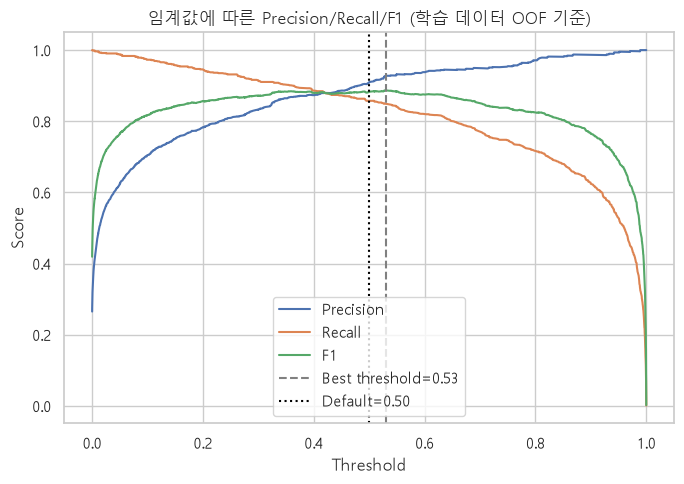

F1 최적 임계값: 0.530 (OOF F1=0.8868, Precision=0.9279, Recall=0.8492)


In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

oof_proba = cross_val_predict(final_model, X_train_scaled, y_train, cv=cv, method="predict_proba")[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = f1s[:-1].argmax()
best_threshold = thresholds[best_idx]

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1s[:-1], label="F1")
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"Best threshold={best_threshold:.2f}")
plt.axvline(0.5, color="black", linestyle=":", label="Default=0.50")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("임계값에 따른 Precision/Recall/F1 (학습 데이터 OOF 기준)")
plt.tight_layout()
plt.show()

print(f"F1 최적 임계값: {best_threshold:.3f} (OOF F1={f1s[best_idx]:.4f}, "
      f"Precision={precisions[best_idx]:.4f}, Recall={recalls[best_idx]:.4f})")

In [25]:
y_pred_thresh = (y_proba_final >= best_threshold).astype(int)

threshold_scores = {
    "Accuracy": accuracy_score(y_test, y_pred_thresh),
    "Precision": precision_score(y_test, y_pred_thresh),
    "Recall": recall_score(y_test, y_pred_thresh),
    "F1": f1_score(y_test, y_pred_thresh),
    "ROC-AUC": final_scores["ROC-AUC"],  # 확률 기반 지표라 임계값에 영향받지 않음
}

pd.DataFrame({
    "임계값 0.5": final_scores,
    f"임계값 {best_threshold:.2f}": threshold_scores,
}).round(4)

,임계값 0.5,임계값 0.53
Accuracy,0.9450,0.9438
Precision,0.9118,0.9154
Recall,0.8774,0.8679
F1,0.8942,0.8910
ROC-AUC,0.9804,0.9804


OOF 기준으로 찾은 최적 임계값(0.53)은 학습 데이터에서는 F1 0.8868로 기본값(0.5)보다 높았지만, 정작 테스트 세트에 적용하면 F1이 0.8942 → 0.8910으로 오히려 소폭 하락한다. 즉 이번 데이터/분할에서는 기본 임계값 0.5가 이미 충분히 좋아 추가 이득이 크지 않았다 — 이는 임계값 튜닝이 항상 성능을 개선하지는 않으며, 학습/검증 분할에 따른 변동성이 존재함을 보여주는 정직한 사례다. 다만 재현율을 precision보다 우선하는 비즈니스 정책이라면 임계값을 의도적으로 낮춰(예: 0.4) 이탈 위험군을 더 폭넓게 잡아내는 선택도 가능하다.

### 9.6 최종 모델 피처 중요도

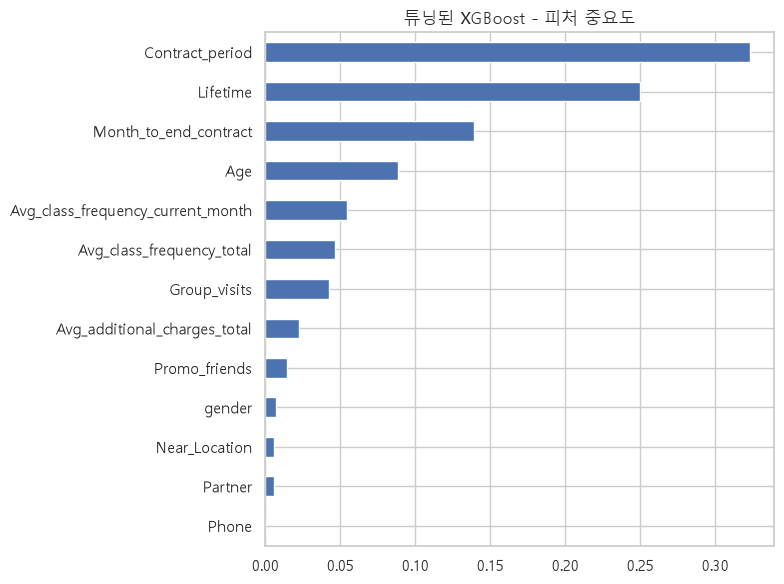

In [26]:
final_importance = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
final_importance.plot(kind="barh", color="#4C72B0")
plt.title("튜닝된 XGBoost - 피처 중요도")
plt.tight_layout()
plt.show()

튜닝된 XGBoost에서도 `Contract_period`(계약 기간, 중요도 0.32), `Lifetime`(이용 개월 수, 0.25), `Month_to_end_contract`(계약 만료까지 남은 기간, 0.14)가 가장 중요한 3개 피처로, baseline 모델(섹션 6)의 결론과 일치한다. 흥미로운 점은 계약 관련 변수 3개의 중요도 합이 약 0.71로 전체의 대부분을 차지한다는 것 — 이는 8장에서 확인한 클러스터 프로파일(계약 기간이 짧고 방문 빈도가 낮은 Cluster 2의 이탈률이 56%에 달했던 것)과도 정확히 맞아떨어진다.

## 10. 최종 결론 (군집화 + 고도화 반영)

- **군집화(K-Means, k=4)**: 회원을 4개 세그먼트로 나눈 결과, 계약 기간이 짧고(1.8개월) 방문 빈도가 낮은(0.95) 세그먼트(Cluster 2, 전체의 37%)의 이탈률이 56%에 달해 압도적인 고위험군으로 드러났다. 반대로 장기 계약(10.8개월) 세그먼트(Cluster 1)는 이탈률이 3%에 불과했다. 다만 이 군집 레이블을 분류 모델의 피처로 추가했을 때의 효과는 모델별로 엇갈렸다(선형모델은 소폭 개선, 트리 모델은 변화 없음/소폭 하락) — 트리 모델은 어차피 원본 피처로 유사한 분기를 스스로 학습하기 때문이다. 따라서 군집화의 가장 큰 가치는 예측 성능 자체보다 **회원 세그먼트를 명시적으로 정의해 리텐션 캠페인을 차등 설계**할 수 있다는 데 있다.
- **모델 고도화**: XGBoost를 추가하고 하이퍼파라미터를 튜닝한 결과, baseline(Gradient Boosting) 대비 테스트 F1이 0.8905 → 0.8942, 재현율이 0.8632 → 0.8774, ROC-AUC가 0.9774 → 0.9804로 개선되었다. SMOTE는 재현율을 크게 끌어올리지만(F1은 비슷하거나 소폭 하락) 정밀도를 희생하는 트레이드오프가 뚜렷했고, 임계값 튜닝은 이번 데이터 분할에서는 뚜렷한 추가 이득을 주지 못했다 — 두 기법 모두 "만능 개선책"이 아니라 비즈니스 목표(재현율 우선 여부)에 따라 선택적으로 적용해야 하는 도구임을 확인했다.
- **최종 피처 중요도**: 튜닝된 모델에서도 `Contract_period`, `Lifetime`, `Month_to_end_contract` 등 계약·이용기간 관련 변수가 이탈 예측의 핵심이었으며, 이는 군집 분석 결과와도 서로를 뒷받침한다.
- **비즈니스 제언**: (1) Cluster 2 유형(단기계약·저빈도) 회원에게는 장기 계약 전환 혜택이나 그룹 수업 추천 등으로 방문 빈도를 끌어올리는 캠페인을, (2) 모델의 이탈 확률(`predict_proba`)이 높은 회원에게는 계약 만료 전 사전 컨택을, 우선순위로 실행할 것을 제안한다.
- **한계 및 추가 개선 방향**: 시간에 따른 변화(예: 최근 방문 빈도 추세, 지출 변화율)를 피처로 추가하면 추가 성능 향상 여지가 있다. 또한 이번 튜닝은 XGBoost 한 모델에 국한했으므로, Random Forest·Gradient Boosting에도 동일한 탐색을 적용해 비교하거나, 스태킹(stacking) 앙상블로 여러 모델을 결합하는 것도 다음 단계로 고려할 수 있다.

## 11. 이탈 방지 시뮬레이션 (Counterfactual 분석)

이탈률을 예측하는 것 자체는 목적이 아니라 수단이다 — 실제로 방문 빈도나 계약 조건을 개선했을 때 이탈 확률이 얼마나 낮아지는지 정량적으로 보여줘야 리텐션 전략에 활용할 수 있다.

이를 위해 **테스트 세트에서 실제로 이탈한 회원**을 대상으로, 8장에서 확인한 저이탈 세그먼트(Cluster, 이탈률이 가장 낮은 군집)의 평균 수준까지 `Contract_period`(계약 기간), `Lifetime`(가입 후 경과 기간), `Avg_class_frequency_total`(전체 기간 평균 방문 빈도), `Month_to_end_contract`(잔여 계약 기간)를 **각각 하나씩** 상향 조정한다(원래 값이 이미 기준보다 높으면 그대로 둔다). 조정 전/후를 튜닝된 XGBoost 모델(`final_model`)에 넣어 예측 이탈확률이 얼마나 낮아지는지 비교한다.

In [27]:
cluster_targets = profile.groupby("Cluster")[
    ["Contract_period", "Lifetime", "Avg_class_frequency_total", "Month_to_end_contract", "Churn"]
].mean().rename(columns={"Churn": "이탈률"})

low_churn_cluster = cluster_targets["이탈률"].idxmin()
target_values = cluster_targets.loc[low_churn_cluster]

print(f"기준(저이탈) 세그먼트: Cluster {low_churn_cluster} (이탈률 {target_values['이탈률']:.1%})")
cluster_targets.round(3)

기준(저이탈) 세그먼트: Cluster 1 (이탈률 3.1%)


,Contract_period,Lifetime,Avg_class_frequency_total,Month_to_end_contract,이탈률
Cluster,,,,,
0,4.615,3.972,1.838,4.338,0.265
1,10.812,4.737,1.952,9.936,0.031
2,1.829,2.278,1.209,1.743,0.561
3,2.454,4.777,2.730,2.299,0.087


In [28]:
cluster_targets_full = profile.groupby("Cluster")[
    ["Contract_period", "Lifetime", "Avg_class_frequency_total",
     "Avg_class_frequency_current_month", "Month_to_end_contract", "Churn"]
].mean()
cluster_targets_full.round(3)

,Contract_period,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Month_to_end_contract,Churn
Cluster,,,,,,
0,4.615,3.972,1.838,1.706,4.338,0.265
1,10.812,4.737,1.952,1.943,9.936,0.031
2,1.829,2.278,1.209,0.952,1.743,0.561
3,2.454,4.777,2.730,2.722,2.299,0.087


In [29]:
features_to_adjust = ["Contract_period", "Lifetime", "Avg_class_frequency_total", "Month_to_end_contract"]

X_test_churned_raw = X_test[y_test == 1].reset_index(drop=True)
proba_before = final_model.predict_proba(scaler.transform(X_test_churned_raw))[:, 1]

print(f"테스트 세트 내 실제 이탈 회원 수: {len(X_test_churned_raw)}")
print(f"조정 전 평균 예측 이탈확률: {proba_before.mean():.4f}")

테스트 세트 내 실제 이탈 회원 수: 212
조정 전 평균 예측 이탈확률: 0.8406


In [30]:
sim_records = []
for feat in features_to_adjust:
    X_cf = X_test_churned_raw.copy()
    target = target_values[feat]
    X_cf[feat] = np.maximum(X_cf[feat], target)
    proba_after = final_model.predict_proba(scaler.transform(X_cf))[:, 1]

    sim_records.append({
        "피처": feat,
        "기준값(Cluster 평균)": target,
        "조정 전 평균 이탈확률": proba_before.mean(),
        "조정 후 평균 이탈확률": proba_after.mean(),
        "평균 감소폭(%p)": (proba_before.mean() - proba_after.mean()) * 100,
        "확률이 감소한 회원 비율": (proba_after < proba_before).mean(),
    })

sim_df = pd.DataFrame(sim_records).set_index("피처")
sim_df.sort_values("평균 감소폭(%p)", ascending=False).round(4)

,기준값(Cluster 평균),조정 전 평균 이탈확률,조정 후 평균 이탈확률,평균 감소폭(%p),확률이 감소한 회원 비율
피처,,,,,
Lifetime,4.7372,0.8406,0.5046,33.6082,0.9623
Month_to_end_contract,9.9364,0.8406,0.7311,10.9553,0.9717
Contract_period,10.8117,0.8406,0.7846,5.5993,0.8538
Avg_class_frequency_total,1.9522,0.8406,0.9205,-7.9840,0.0330


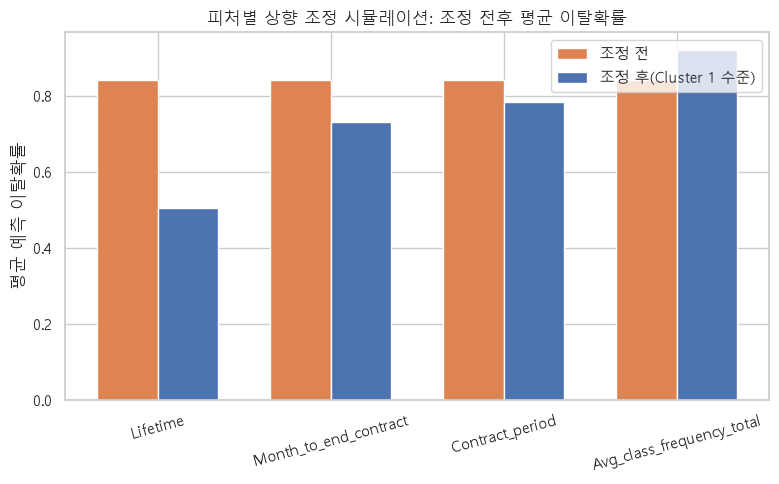

In [31]:
plt.figure(figsize=(8, 5))
order = sim_df.sort_values("평균 감소폭(%p)", ascending=False).index
x = np.arange(len(order))
width = 0.35
plt.bar(x - width/2, sim_df.loc[order, "조정 전 평균 이탈확률"], width, label="조정 전", color="#DD8452")
plt.bar(x + width/2, sim_df.loc[order, "조정 후 평균 이탈확률"], width, label=f"조정 후(Cluster {low_churn_cluster} 수준)", color="#4C72B0")
plt.xticks(x, order, rotation=15)
plt.ylabel("평균 예측 이탈확률")
plt.title("피처별 상향 조정 시뮬레이션: 조정 전후 평균 이탈확률")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
X_cf_all = X_test_churned_raw.copy()
for feat in features_to_adjust:
    X_cf_all[feat] = np.maximum(X_cf_all[feat], target_values[feat])
proba_after_all = final_model.predict_proba(scaler.transform(X_cf_all))[:, 1]

print(f"4개 피처 동시 조정 후 평균 예측 이탈확률: {proba_after_all.mean():.4f} "
      f"(조정 전 {proba_before.mean():.4f} 대비 {(proba_before.mean() - proba_after_all.mean()) * 100:.2f}%p 감소)")

4개 피처 동시 조정 후 평균 예측 이탈확률: 0.5927 (조정 전 0.8406 대비 24.79%p 감소)


### 11.1 방문 빈도 조정 결과가 반대로 나온 이유 확인

`Avg_class_frequency_total`만 올렸을 때 이탈확률이 오히려 상승했다. `Avg_class_frequency_total`(전체 기간 평균 방문 빈도)과 `Avg_class_frequency_current_month`(이번 달 방문 빈도)는 2장 상관관계 분석에서 이미 다중공선성이 있다고 확인한 피처 쌍이다 — 전체 평균만 인위적으로 높이고 이번 달 방문 빈도는 그대로 두면, 모델 입장에서는 "예전엔 자주 왔는데 최근 들어 뜸해진" 회원으로 보여 오히려 이탈 신호가 강해졌을 가능성이 있다. 실제로 방문 빈도가 개선된 상황이라면 두 피처가 함께 오르는 것이 현실적이므로, 두 피처를 동시에 저이탈 세그먼트 수준까지 올렸을 때의 효과를 확인한다.

In [33]:
current_month_target = cluster_targets_full.loc[low_churn_cluster, "Avg_class_frequency_current_month"]

X_cf_freq_both = X_test_churned_raw.copy()
X_cf_freq_both["Avg_class_frequency_total"] = np.maximum(
    X_cf_freq_both["Avg_class_frequency_total"], target_values["Avg_class_frequency_total"]
)
X_cf_freq_both["Avg_class_frequency_current_month"] = np.maximum(
    X_cf_freq_both["Avg_class_frequency_current_month"], current_month_target
)
proba_after_freq_both = final_model.predict_proba(scaler.transform(X_cf_freq_both))[:, 1]

print(f"방문 빈도 2개 피처(전체 평균 + 이번 달) 동시 조정 후 평균 예측 이탈확률: {proba_after_freq_both.mean():.4f} "
      f"(조정 전 {proba_before.mean():.4f} 대비 {(proba_before.mean() - proba_after_freq_both.mean()) * 100:.2f}%p 변화)")

방문 빈도 2개 피처(전체 평균 + 이번 달) 동시 조정 후 평균 예측 이탈확률: 0.6258 (조정 전 0.8406 대비 21.48%p 변화)


### 11.2 결과 해석 및 비즈니스 제언

**피처별 단독 조정 효과 (조정 전 평균 이탈확률 0.8406 기준)**

| 피처 | 저이탈 세그먼트(Cluster 1) 기준값 | 조정 후 평균 이탈확률 | 평균 감소폭 | 확률이 감소한 회원 비율 |
|---|---|---|---|---|
| `Lifetime` | 4.74개월 | 0.5046 | **33.6%p** | 96.2% |
| `Month_to_end_contract` | 9.94개월 | 0.7311 | **11.0%p** | 97.2% |
| `Contract_period` | 10.81개월 | 0.7846 | **5.6%p** | 85.4% |
| `Avg_class_frequency_total`(단독) | 1.95 | 0.9205 | **-8.0%p (악화)** | 3.3% |

- **`Lifetime`·`Month_to_end_contract`·`Contract_period`**는 상향 조정만으로도 이탈확률이 뚜렷하고 일관되게(회원 85~97%에서) 낮아졌다. 특히 `Lifetime`의 효과가 가장 크다는 것은 "가입 초반 이탈"이 전체 이탈의 핵심 동인임을 보여준다 — 다만 `Lifetime`은 이미 지나간 이용 기간이라 회원에게 직접 개입할 수 있는 지렛대는 아니며, 오히려 "가입 후 몇 개월 이내 온보딩/리텐션 케어가 왜 중요한지"를 뒷받침하는 진단 지표로 해석해야 한다. 반면 `Contract_period`·`Month_to_end_contract`는 장기 계약 전환 프로모션처럼 실제로 개입 가능한 지렛대다.
- **`Avg_class_frequency_total`만 단독으로 올렸을 때는 오히려 이탈확률이 악화**됐다. 2장에서 확인한 대로 이 피처는 `Avg_class_frequency_current_month`와 다중공선성이 있는데, 전체 기간 평균만 인위적으로 높이고 이번 달 방문 빈도는 그대로 두면 모델 입장에서는 "예전엔 자주 왔는데 최근 들어 발길이 뜸해진" 회원처럼 보여 이탈 신호가 오히려 강해진 것으로 보인다. 실제로 두 방문 빈도 피처를 **함께** 저이탈 세그먼트 수준까지 올리자(11.1절) 이탈확률이 0.8406 → 0.6258로 **21.5%p 감소**해, 방문 빈도 증가가 이탈 방지에 실제로 유효하다는 최초 가설이 확인됐다. 즉 방문 빈도 개선 효과를 정확히 측정하려면 "이번 달 방문"과 "누적 평균 방문"이 함께 개선되는 현실적인 시나리오로 봐야 하며, 둘 중 하나만 형식적으로 좋아 보이는 경우는 오히려 위험 신호로 오독될 수 있다.
- 4개 피처를 동시에 상향 조정한 경우(11장 마지막 셀) 이탈확률이 0.8406 → 0.5927로 24.8%p 감소했는데, 여기에는 `Avg_class_frequency_total` 단독 조정의 왜곡된 효과가 일부 섞여 있으므로, 방문 빈도 관련 개선 효과는 11.1절의 21.5%p(두 피처 동시 조정) 수치를 참고하는 것이 더 정확하다.

**비즈니스 제언**

1. **초반 이탈 방지가 최우선 과제**: `Lifetime`의 효과가 가장 컸다는 것은 가입 초기 회원의 이탈 위험이 특히 높다는 뜻이다. 가입 후 1~3개월 이내 회원에게 온보딩 체크인, 초기 방문 리마인드 등 선제적 케어를 집중해야 한다.
2. **장기 계약 전환 유도**: `Contract_period`·`Month_to_end_contract` 개선 효과가 확인된 만큼, 계약 만료가 임박한 회원에게 장기 계약 전환 할인 등을 제안하는 캠페인이 실제로 이탈 방지에 기여할 것으로 기대된다.
3. **방문 빈도 제고 캠페인은 유효하되, "이번 달 방문"을 실제로 끌어올려야 함**: 그룹 수업 추천, 방문 리마인드 알림 등으로 당장의 방문 빈도를 높이는 것이 이탈 방지에 실질적 효과가 있다(21.5%p 감소 확인). 다만 과거 누적 평균 방문 빈도 수치 자체를 관리 지표로 쓰는 것은 최근 방문 추세를 놓치면 오히려 이탈 위험을 과소평가할 수 있으므로, 캠페인 효과 측정은 반드시 최근(이번 달) 방문 빈도 기준으로 해야 한다.